# Combined All-Complexity Network


This notebook combines all complexity upgrades into one model and reports full diagnostics.


/Users/jackhenry/Library/CloudStorage/OneDrive-UniversityofCambridge/IIB Project work/Radar_SNN_3/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Artifacts root: /Users/jackhenry/Library/CloudStorage/OneDrive-UniversityofCambridge/IIB Project work/Radar_SNN_3/artifacts_steps/step6_combined_all
DEVICE: cpu
Using params: {'hidden': 128, 'beta': 0.95, 'lr': 0.0009, 'batch_size': 64, 'lambda_az_max': 1.8, 'az_warmup_epochs': 10, 'noise_std': 0.012, 'reverb_level': 0.14}
Train: 1120 Test: 280
Saved plot: artifacts_steps/step6_combined_all/plots/signal_example_step6_combined.png


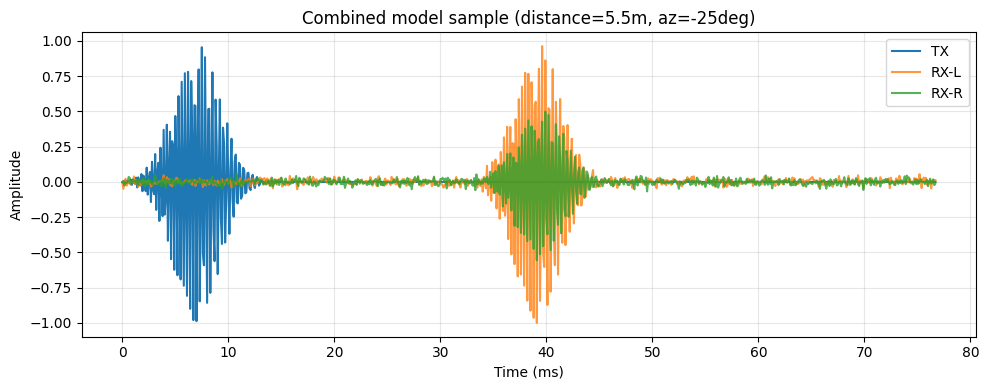

Trainable params: 53197


KeyboardInterrupt: 

In [1]:

# ============================================================================
# Combined Network: All Complexity Upgrades
# - FM chirp TX
# - Frequency filterbank receiver front-end
# - Continuous range simulation + binned labels
# - Realistic azimuth simulation (ITD + frequency-dependent ILD + noise/reverb)
# - Parallel multitask branches (range + azimuth)
# - Trainable delay parameters in both branches
# - Per-task loss weighting schedule
# - Rich diagnostics: confusion, calibration, per-bin error, delay plots
# ============================================================================

from pathlib import Path
import json
import random
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import optuna
import snntorch as snn


# ----------------------------------
# Reproducibility and artifact paths
# ----------------------------------
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

ART = Path("artifacts_steps/step6_combined_all")
PLOT_DIR = ART / "plots"
CKPT_DIR = ART / "checkpoints"
PARAM_DIR = ART / "params"
OPTUNA_DIR = ART / "optuna"

for d in [ART, PLOT_DIR, CKPT_DIR, PARAM_DIR, OPTUNA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = CKPT_DIR / "model_step6_combined.pt"
BEST_PARAMS_PATH = PARAM_DIR / "best_params_step6_combined.json"
METRICS_PATH = ART / "metrics_step6_combined.json"
OPTUNA_DB_PATH = OPTUNA_DIR / "step6_combined.sqlite3"

print("Artifacts root:", ART.resolve())


# -------------------------
# Device selection (CPU/GPU)
# -------------------------
if False and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print("DEVICE:", DEVICE)


# ----------------------
# Run/tuning configuration
# ----------------------
# By default this notebook runs a direct training pass.
# Set RUN_OPTUNA=True for a lightweight tuning pass.
RUN_OPTUNA = False
N_TRIALS = 8
TRIAL_EPOCHS = 8
FINAL_EPOCHS = 18

FORCE_RETRAIN = False
LOAD_CHECKPOINT_IF_AVAILABLE = True


# ---------------------
# Simulation definitions
# ---------------------
DT = 1e-4
FS = 1.0 / DT
T_STEPS = 768
TIME = np.arange(T_STEPS) * DT
SPEED_OF_SOUND = 343.0

RANGE_MIN, RANGE_MAX = 0.5, 10.0
RANGE_CLASSES = 20
RANGE_BINS = np.linspace(RANGE_MIN, RANGE_MAX, RANGE_CLASSES + 1)
RANGE_CENTERS = 0.5 * (RANGE_BINS[:-1] + RANGE_BINS[1:])

AZ_MIN, AZ_MAX = -45.0, 45.0
AZ_CLASSES = 9
AZ_BINS = np.linspace(AZ_MIN, AZ_MAX, AZ_CLASSES + 1)
AZ_CENTERS = 0.5 * (AZ_BINS[:-1] + AZ_BINS[1:])

N_SAMPLES = 1400

# Initial trainable delay taps.
INIT_DELAYS = torch.linspace(0, 640, 24)

DEFAULT_PARAMS = {
    "hidden": 128,
    "beta": 0.95,
    "lr": 9e-4,
    "batch_size": 64,
    "lambda_az_max": 1.8,
    "az_warmup_epochs": 10,
    "noise_std": 0.012,
    "reverb_level": 0.14,
}


# ---------------
# Helper utilities
# ---------------
def save_fig(name: str):
    p = PLOT_DIR / name
    plt.savefig(p, dpi=150, bbox_inches="tight")
    print("Saved plot:", p)


def save_json(path: Path, payload: dict):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)


def load_json(path: Path):
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def moving_average(x: np.ndarray, k: int = 9) -> np.ndarray:
    ker = np.ones(k, dtype=np.float32) / k
    return np.convolve(x, ker, mode="same")


def range_bin(d: float) -> int:
    return int(np.digitize(d, RANGE_BINS[1:-1], right=False))


def az_bin(a: float) -> int:
    return int(np.digitize(a, AZ_BINS[1:-1], right=False))


def apply_delay(sig: np.ndarray, d: int) -> np.ndarray:
    out = np.zeros_like(sig)
    if d < len(sig):
        out[d:] = sig[: len(sig) - d]
    return out


# ------------------------------------
# Waveform and realistic ear simulation
# ------------------------------------
def chirp_tx() -> np.ndarray:
    dur = 0.02
    f_hi, f_lo = 4200.0, 1200.0
    k = (f_lo - f_hi) / dur

    t = TIME
    tc = np.minimum(t, dur)
    phase = 2 * np.pi * (f_hi * tc + 0.5 * k * tc ** 2)

    env = np.exp(-0.5 * ((np.arange(T_STEPS) - 70) / 22.0) ** 2)
    sig = np.sin(phase) * env
    sig[t > dur] = 0.0
    return sig.astype(np.float32)


def make_realistic_binaural_sample(distance_m: float, az_deg: float, noise_std: float, reverb_level: float):
    """
    Combined realistic simulation:
    - Range delay from distance.
    - ITD from azimuth.
    - Frequency-dependent ILD approximation.
    - Reverb tails.
    - Additive noise.
    """
    tx = chirp_tx()

    base_delay = int(round((2.0 * distance_m / SPEED_OF_SOUND) / DT))

    # ITD approximation.
    max_itd_sec = 0.0006
    itd = max_itd_sec * np.sin(np.deg2rad(az_deg))
    itd_steps = int(round(itd / DT))

    extra_left = max(0, itd_steps)
    extra_right = max(0, -itd_steps)

    # Base delayed echo.
    echo = apply_delay(tx, base_delay) * 0.55

    # Frequency-dependent ILD approximation with low/high split.
    low = moving_average(echo, k=11)
    high = echo - low

    az_norm = float(np.clip(np.sin(np.deg2rad(az_deg)), -1.0, 1.0))
    ild_strength = 0.52 * abs(az_norm)

    g_hp_l = 1.0 - ild_strength * np.sign(az_norm)
    g_hp_r = 1.0 + ild_strength * np.sign(az_norm)

    contra_drop = 1.0 - 0.28 * abs(az_norm)
    if az_norm >= 0:
        broad_l, broad_r = contra_drop, 1.0
    else:
        broad_l, broad_r = 1.0, contra_drop

    left = broad_l * (low + g_hp_l * high)
    right = broad_r * (low + g_hp_r * high)

    # Ear-specific ITD shift.
    left = apply_delay(left, extra_left)
    right = apply_delay(right, extra_right)

    # Simple reverb copies.
    for ds, a in [(7, 0.20), (15, 0.12), (29, 0.08)]:
        left += reverb_level * a * apply_delay(left, ds)
        right += reverb_level * a * apply_delay(right, ds)

    # Add noise.
    left += np.random.normal(0.0, noise_std, size=left.shape).astype(np.float32)
    right += np.random.normal(0.0, noise_std, size=right.shape).astype(np.float32)

    # Light normalization.
    m = max(np.max(np.abs(left)), np.max(np.abs(right)), 1e-6)
    left = (left / m).astype(np.float32)
    right = (right / m).astype(np.float32)

    return tx.astype(np.float32), left, right


# ---------------------
# Dataset construction
# ---------------------
def build_dataset(params, seed=SEED):
    rng = np.random.default_rng(seed)

    ranges = rng.uniform(RANGE_MIN, RANGE_MAX, size=N_SAMPLES)
    azimuths = rng.uniform(AZ_MIN, AZ_MAX, size=N_SAMPLES)

    txs, lfs, rfs, yr, ya = [], [], [], [], []

    for d, a in zip(ranges, azimuths):
        tx, lf, rf = make_realistic_binaural_sample(
            float(d),
            float(a),
            noise_std=float(params["noise_std"]),
            reverb_level=float(params["reverb_level"]),
        )
        txs.append(tx)
        lfs.append(lf)
        rfs.append(rf)
        yr.append(range_bin(float(d)))
        ya.append(az_bin(float(a)))

    txs = np.stack(txs)
    lfs = np.stack(lfs)
    rfs = np.stack(rfs)
    yr = np.array(yr, dtype=np.int64)
    ya = np.array(ya, dtype=np.int64)

    perm = rng.permutation(N_SAMPLES)
    txs, lfs, rfs, yr, ya = txs[perm], lfs[perm], rfs[perm], yr[perm], ya[perm]

    split = int(0.8 * N_SAMPLES)
    return (
        txs[:split], lfs[:split], rfs[:split], yr[:split], ya[:split],
        txs[split:], lfs[split:], rfs[split:], yr[split:], ya[split:],
    )


def make_loaders(data, batch_size):
    Xtx_tr, Xlf_tr, Xrf_tr, yr_tr, ya_tr, Xtx_te, Xlf_te, Xrf_te, yr_te, ya_te = data

    train_ds = TensorDataset(
        torch.from_numpy(Xtx_tr),
        torch.from_numpy(Xlf_tr),
        torch.from_numpy(Xrf_tr),
        torch.from_numpy(yr_tr),
        torch.from_numpy(ya_tr),
    )
    test_ds = TensorDataset(
        torch.from_numpy(Xtx_te),
        torch.from_numpy(Xlf_te),
        torch.from_numpy(Xrf_te),
        torch.from_numpy(yr_te),
        torch.from_numpy(ya_te),
    )

    tr_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    te_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_ds, test_ds, tr_loader, te_loader


# -------------------------------
# Front-end filterbank and delays
# -------------------------------
class FrequencyFilterBank(nn.Module):
    """Fixed sinusoid filterbank front-end."""

    def __init__(self, num_channels=8, kernel_size=33, fs=FS, f_low=800.0, f_high=4500.0):
        super().__init__()
        self.conv = nn.Conv1d(1, num_channels, kernel_size=kernel_size, padding=kernel_size // 2, bias=False)

        t = np.arange(kernel_size) / fs
        t = t - t.mean()
        win = np.hanning(kernel_size)
        freqs = np.linspace(f_low, f_high, num_channels)

        kernels = []
        for f in freqs:
            k = np.sin(2 * np.pi * f * t) * win
            k = k / (np.linalg.norm(k) + 1e-8)
            kernels.append(k.astype(np.float32))

        w = torch.from_numpy(np.stack(kernels)[:, None, :])
        with torch.no_grad():
            self.conv.weight.copy_(w)
        self.conv.weight.requires_grad = False

    def forward(self, x):
        # x: [T,B,1] -> [T,B,F]
        xb = x.permute(1, 2, 0)
        y = self.conv(xb)
        return y.permute(2, 0, 1)


class TrainableDelayBankMulti(nn.Module):
    """
    Trainable soft delay bank for multi-channel inputs.
    Uses linear interpolation between integer sample positions.
    """

    def __init__(self, init_delays, max_delay=640):
        super().__init__()
        self.max_delay = float(max_delay)

        init = torch.clamp(init_delays / self.max_delay, 1e-4, 1 - 1e-4)
        raw = torch.log(init / (1 - init))
        self.raw_delays = nn.Parameter(raw)

    def delays(self):
        return self.max_delay * torch.sigmoid(self.raw_delays)

    def forward(self, x):
        # x: [T,B,F]
        T, B, Fch = x.shape
        D = self.raw_delays.numel()

        # Pad in time so delayed indexing remains valid.
        pad_len = int(self.max_delay) + 2
        x_pad = F.pad(x, (0, 0, 0, 0, pad_len, 0))  # [T+pad, B, F]

        t = torch.arange(T, device=x.device, dtype=torch.float32)[:, None] + pad_len
        d = self.delays()[None, :]                  # [1,D]
        idx_f = t - d                               # [T,D]

        idx0 = torch.floor(idx_f).long().clamp(0, x_pad.shape[0] - 1)
        idx1 = (idx0 + 1).clamp(0, x_pad.shape[0] - 1)

        w = (idx_f - idx0.float())[:, :, None, None]  # [T,D,1,1]

        x0 = x_pad[idx0]  # [T,D,B,F]
        x1 = x_pad[idx1]  # [T,D,B,F]

        out = (1.0 - w) * x0 + w * x1             # [T,D,B,F]
        out = out.permute(0, 2, 3, 1).contiguous() # [T,B,F,D]
        return out


# -----------------------------
# Combined multitask SNN model
# -----------------------------
class CombinedAllComplexitySNN(nn.Module):
    """
    Full model with all complexity pieces combined.
    """

    def __init__(self, init_delays, freq_ch=8, hidden=128, beta=0.95):
        super().__init__()

        self.fb = FrequencyFilterBank(num_channels=freq_ch)

        # Separate trainable delay banks for each task branch.
        self.range_delay = TrainableDelayBankMulti(init_delays=init_delays, max_delay=640)
        self.az_delay = TrainableDelayBankMulti(init_delays=init_delays, max_delay=640)

        feat_dim = freq_ch * len(init_delays)

        self.fc_r1 = nn.Linear(feat_dim, hidden)
        self.lif_r1 = snn.Leaky(beta=beta)
        self.fc_r2 = nn.Linear(hidden, RANGE_CLASSES)
        self.lif_r2 = snn.Leaky(beta=beta)

        self.fc_a1 = nn.Linear(feat_dim, hidden)
        self.lif_a1 = snn.Leaky(beta=beta)
        self.fc_a2 = nn.Linear(hidden, AZ_CLASSES)
        self.lif_a2 = snn.Leaky(beta=beta)

    def forward(self, tx, lf, rf):
        txf = self.fb(tx)
        lff = self.fb(lf)
        rff = self.fb(rf)

        mid = 0.5 * (lff + rff)
        diff = rff - lff

        dtx_r = self.range_delay(txf)
        dtx_a = self.az_delay(txf)

        feat_r = (dtx_r * mid[..., None]).reshape(txf.shape[0], txf.shape[1], -1)
        feat_a = (dtx_a * diff[..., None]).reshape(txf.shape[0], txf.shape[1], -1)

        self.lif_r1.reset_mem(); self.lif_r2.reset_mem()
        self.lif_a1.reset_mem(); self.lif_a2.reset_mem()

        mr1 = mr2 = ma1 = ma2 = None
        out_r = []
        out_a = []

        for t in range(feat_r.shape[0]):
            sr1, mr1 = self.lif_r1(self.fc_r1(feat_r[t]), mr1)
            sr2, mr2 = self.lif_r2(self.fc_r2(sr1), mr2)

            sa1, ma1 = self.lif_a1(self.fc_a1(feat_a[t]), ma1)
            sa2, ma2 = self.lif_a2(self.fc_a2(sa1), ma2)

            out_r.append(sr2)
            out_a.append(sa2)

        return torch.stack(out_r, dim=0), torch.stack(out_a, dim=0)


# ------------------------------------------------------
# Evaluation and training with weighted multitask losses
# ------------------------------------------------------
def az_weight_for_epoch(epoch_idx, warmup_epochs, lambda_az_max):
    start = 0.2
    if warmup_epochs <= 1:
        return lambda_az_max
    alpha = min(1.0, (epoch_idx - 1) / float(warmup_epochs - 1))
    return start + alpha * (lambda_az_max - start)


def evaluate(model, loader, ce):
    model.eval()
    total_loss = 0.0
    cor_r = 0
    cor_a = 0
    tot = 0

    yr_t, yr_p, yr_conf = [], [], []
    ya_t, ya_p, ya_conf = [], [], []

    with torch.no_grad():
        for txb, lfb, rfb, yrb, yab in loader:
            txb = txb.to(DEVICE)
            lfb = lfb.to(DEVICE)
            rfb = rfb.to(DEVICE)
            yrb = yrb.to(DEVICE)
            yab = yab.to(DEVICE)

            tx_t = txb.unsqueeze(-1).permute(1, 0, 2)
            lf_t = lfb.unsqueeze(-1).permute(1, 0, 2)
            rf_t = rfb.unsqueeze(-1).permute(1, 0, 2)

            spk_r, spk_a = model(tx_t, lf_t, rf_t)
            cnt_r = spk_r.sum(dim=0)
            cnt_a = spk_a.sum(dim=0)

            loss = ce(cnt_r, yrb) + ce(cnt_a, yab)
            total_loss += loss.item() * yrb.size(0)

            prob_r = torch.softmax(cnt_r, dim=1)
            conf_r, pred_r = prob_r.max(dim=1)

            prob_a = torch.softmax(cnt_a, dim=1)
            conf_a, pred_a = prob_a.max(dim=1)

            cor_r += (pred_r == yrb).sum().item()
            cor_a += (pred_a == yab).sum().item()
            tot += yrb.size(0)

            yr_t.append(yrb.cpu().numpy())
            yr_p.append(pred_r.cpu().numpy())
            yr_conf.append(conf_r.cpu().numpy())

            ya_t.append(yab.cpu().numpy())
            ya_p.append(pred_a.cpu().numpy())
            ya_conf.append(conf_a.cpu().numpy())

    return {
        "loss": total_loss / tot,
        "range_acc": cor_r / tot,
        "az_acc": cor_a / tot,
        "yr_true": np.concatenate(yr_t),
        "yr_pred": np.concatenate(yr_p),
        "yr_conf": np.concatenate(yr_conf),
        "ya_true": np.concatenate(ya_t),
        "ya_pred": np.concatenate(ya_p),
        "ya_conf": np.concatenate(ya_conf),
    }


def train_model(model, train_loader, test_loader, params, epochs, verbose=True):
    ce = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=params["lr"])

    hist = {
        "train_loss": [],
        "test_loss": [],
        "range_train_acc": [],
        "range_test_acc": [],
        "az_train_acc": [],
        "az_test_acc": [],
        "lambda_az": [],
    }

    best_state = None
    best_test_loss = float("inf")

    for ep in range(1, epochs + 1):
        model.train()
        run_loss = 0.0
        cor_r = 0
        cor_a = 0
        tot = 0

        lam_az = az_weight_for_epoch(ep, int(params["az_warmup_epochs"]), float(params["lambda_az_max"]))

        for txb, lfb, rfb, yrb, yab in train_loader:
            txb = txb.to(DEVICE)
            lfb = lfb.to(DEVICE)
            rfb = rfb.to(DEVICE)
            yrb = yrb.to(DEVICE)
            yab = yab.to(DEVICE)

            tx_t = txb.unsqueeze(-1).permute(1, 0, 2)
            lf_t = lfb.unsqueeze(-1).permute(1, 0, 2)
            rf_t = rfb.unsqueeze(-1).permute(1, 0, 2)

            opt.zero_grad()
            spk_r, spk_a = model(tx_t, lf_t, rf_t)
            cnt_r = spk_r.sum(dim=0)
            cnt_a = spk_a.sum(dim=0)

            loss_r = ce(cnt_r, yrb)
            loss_a = ce(cnt_a, yab)

            # Delay-regularization term to keep branch delays well-behaved.
            dr = model.range_delay.delays()
            da = model.az_delay.delays()
            reg = 1e-5 * ((dr[1:] - dr[:-1]).abs().mean() + (da[1:] - da[:-1]).abs().mean())

            loss = 1.0 * loss_r + lam_az * loss_a + reg
            loss.backward()
            opt.step()

            run_loss += loss.item() * yrb.size(0)
            pred_r = cnt_r.argmax(dim=1)
            pred_a = cnt_a.argmax(dim=1)
            cor_r += (pred_r == yrb).sum().item()
            cor_a += (pred_a == yab).sum().item()
            tot += yrb.size(0)

        tr_loss = run_loss / tot
        tr_acc_r = cor_r / tot
        tr_acc_a = cor_a / tot

        te = evaluate(model, test_loader, ce)

        hist["train_loss"].append(tr_loss)
        hist["test_loss"].append(te["loss"])
        hist["range_train_acc"].append(tr_acc_r)
        hist["range_test_acc"].append(te["range_acc"])
        hist["az_train_acc"].append(tr_acc_a)
        hist["az_test_acc"].append(te["az_acc"])
        hist["lambda_az"].append(lam_az)

        if te["loss"] < best_test_loss:
            best_test_loss = te["loss"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if verbose and (ep == 1 or ep % 5 == 0 or ep == epochs):
            print(
                f"Epoch {ep:02d}/{epochs} | train_loss={tr_loss:.4f}, test_loss={te['loss']:.4f} | "
                f"range_train={tr_acc_r*100:.1f}%, range_test={te['range_acc']*100:.1f}% | "
                f"az_train={tr_acc_a*100:.1f}%, az_test={te['az_acc']*100:.1f}% | "
                f"lambda_az={lam_az:.3f}"
            )

    return hist, best_state, best_test_loss


# ----------------
# Optuna objective
# ----------------
def objective(trial):
    random.seed(SEED + trial.number)
    np.random.seed(SEED + trial.number)
    torch.manual_seed(SEED + trial.number)

    params = {
        "hidden": trial.suggest_categorical("hidden", [96, 128, 160]),
        "beta": trial.suggest_float("beta", 0.88, 0.99),
        "lr": trial.suggest_float("lr", 2e-4, 3e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128]),
        "lambda_az_max": trial.suggest_float("lambda_az_max", 1.0, 2.4),
        "az_warmup_epochs": trial.suggest_int("az_warmup_epochs", 4, 14),
        "noise_std": trial.suggest_float("noise_std", 0.005, 0.02),
        "reverb_level": trial.suggest_float("reverb_level", 0.08, 0.25),
    }

    data_t = build_dataset(params, seed=SEED)
    _, _, tr_loader, te_loader = make_loaders(data_t, batch_size=params["batch_size"])

    model_t = CombinedAllComplexitySNN(
        init_delays=INIT_DELAYS,
        freq_ch=8,
        hidden=params["hidden"],
        beta=params["beta"],
    ).to(DEVICE)

    hist_t, _, best_test_loss = train_model(
        model_t,
        tr_loader,
        te_loader,
        params=params,
        epochs=TRIAL_EPOCHS,
        verbose=False,
    )

    max_r_test = float(max(hist_t["range_test_acc"]))
    max_a_test = float(max(hist_t["az_test_acc"]))
    trial.set_user_attr("max_range_test_acc", max_r_test)
    trial.set_user_attr("max_az_test_acc", max_a_test)

    return best_test_loss


# --------------------------------
# Select params (optuna or cached)
# --------------------------------
if RUN_OPTUNA:
    storage = f"sqlite:///{OPTUNA_DB_PATH.resolve()}"
    study = optuna.create_study(
        study_name="step6_combined_all",
        storage=storage,
        direction="minimize",
        load_if_exists=True,
    )
    study.optimize(objective, n_trials=N_TRIALS)
    best_params = study.best_params

    save_json(
        BEST_PARAMS_PATH,
        {
            "params": best_params,
            "metadata": {
                "study_name": "step6_combined_all",
                "storage": storage,
                "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
            },
        },
    )
else:
    loaded = load_json(BEST_PARAMS_PATH)
    best_params = loaded["params"] if loaded is not None else DEFAULT_PARAMS.copy()

print("Using params:", best_params)


# -------------------------
# Build data and model run
# -------------------------
data = build_dataset(best_params, seed=SEED)
train_ds, test_ds, train_loader, test_loader = make_loaders(data, batch_size=best_params["batch_size"])
print("Train:", len(train_ds), "Test:", len(test_ds))

# Example visualization.
tx_ex, lf_ex, rf_ex = make_realistic_binaural_sample(5.5, -25.0, best_params["noise_std"], best_params["reverb_level"])
plt.figure(figsize=(10, 4))
plt.plot(TIME*1e3, tx_ex, label="TX")
plt.plot(TIME*1e3, lf_ex, label="RX-L", alpha=0.8)
plt.plot(TIME*1e3, rf_ex, label="RX-R", alpha=0.8)
plt.title("Combined model sample (distance=5.5m, az=-25deg)")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
save_fig("signal_example_step6_combined.png")
plt.show()

model = CombinedAllComplexitySNN(
    init_delays=INIT_DELAYS,
    freq_ch=8,
    hidden=best_params["hidden"],
    beta=best_params["beta"],
).to(DEVICE)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable params:", trainable_params)

if LOAD_CHECKPOINT_IF_AVAILABLE and CHECKPOINT_PATH.exists() and not FORCE_RETRAIN:
    payload = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(payload["model_state_dict"])
    history = payload["history"]
    print("Loaded checkpoint:", CHECKPOINT_PATH)
else:
    history, best_state, _ = train_model(
        model,
        train_loader,
        test_loader,
        params=best_params,
        epochs=FINAL_EPOCHS,
        verbose=True,
    )
    model.load_state_dict(best_state)

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "history": history,
            "params": best_params,
            "trainable_params": trainable_params,
        },
        CHECKPOINT_PATH,
    )
    print("Saved checkpoint:", CHECKPOINT_PATH)


# ----------------------
# Training-curve plots
# ----------------------
epochs = np.arange(1, len(history["train_loss"]) + 1)
fig, ax = plt.subplots(1, 4, figsize=(20, 4.5))

ax[0].plot(epochs, history["train_loss"], label="train")
ax[0].plot(epochs, history["test_loss"], label="test")
ax[0].set_title("Total loss")
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(epochs, np.array(history["range_train_acc"])*100, label="train")
ax[1].plot(epochs, np.array(history["range_test_acc"])*100, label="test")
ax[1].set_title("Range accuracy (%)")
ax[1].grid(alpha=0.3)
ax[1].legend()

ax[2].plot(epochs, np.array(history["az_train_acc"])*100, label="train")
ax[2].plot(epochs, np.array(history["az_test_acc"])*100, label="test")
ax[2].set_title("Azimuth accuracy (%)")
ax[2].grid(alpha=0.3)
ax[2].legend()

ax[3].plot(epochs, history["lambda_az"], color="tab:purple")
ax[3].set_title("Azimuth weight schedule")
ax[3].set_ylabel("lambda_az")
ax[3].grid(alpha=0.3)

for a in ax:
    a.set_xlabel("Epoch")

plt.tight_layout()
save_fig("curves_step6_combined.png")
plt.show()


# ------------------------
# Final eval and analyses
# ------------------------
ce = nn.CrossEntropyLoss()
te = evaluate(model, test_loader, ce)


def confusion_plot(y_true, y_pred, labels, title, filename):
    n = len(labels)
    cm = np.zeros((n, n), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    cmn = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    im0 = axes[0].imshow(cm, cmap="Blues", aspect="auto")
    axes[0].set_title(f"{title} confusion (counts)")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(cmn, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    axes[1].set_title(f"{title} confusion (row-normalized)")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    idx = np.arange(n)
    for a in axes:
        a.set_xticks(idx)
        a.set_yticks(idx)
        a.set_xticklabels(labels, rotation=90)
        a.set_yticklabels(labels)
        a.set_xlabel("Pred")
        a.set_ylabel("True")

    plt.tight_layout()
    save_fig(filename)
    plt.show()


confusion_plot(te["yr_true"], te["yr_pred"], [f"{d:.1f}" for d in RANGE_CENTERS], "Range", "confusion_range_step6_combined.png")
confusion_plot(te["ya_true"], te["ya_pred"], [f"{d:.0f}" for d in AZ_CENTERS], "Azimuth", "confusion_az_step6_combined.png")


# Calibration curves for both tasks.
def calibration_curve_data(y_true, y_pred, y_conf, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.digitize(y_conf, bins[1:-1], right=False)
    accs, confs, counts = [], [], []
    for b in range(n_bins):
        m = idx == b
        if np.any(m):
            accs.append(np.mean(y_pred[m] == y_true[m]))
            confs.append(np.mean(y_conf[m]))
            counts.append(np.sum(m))
        else:
            accs.append(np.nan)
            confs.append(np.nan)
            counts.append(0)
    ece = 0.0
    n = len(y_true)
    for b in range(n_bins):
        if counts[b] > 0:
            ece += (counts[b] / n) * abs(accs[b] - confs[b])
    centers = 0.5 * (bins[:-1] + bins[1:])
    return centers, np.array(accs), np.array(confs), np.array(counts), float(ece)

cent_r, acc_r, conf_r, cnt_r, ece_r = calibration_curve_data(te["yr_true"], te["yr_pred"], te["yr_conf"])
cent_a, acc_a, conf_a, cnt_a, ece_a = calibration_curve_data(te["ya_true"], te["ya_pred"], te["ya_conf"])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0))
for ax, c, a, title, ece in [
    (axes[0], cent_r, acc_r, "Range", ece_r),
    (axes[1], cent_a, acc_a, "Azimuth", ece_a),
]:
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.plot(c, a, marker="o", linewidth=2)
    ax.set_title(f"{title} calibration (ECE={ece:.4f})")
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Accuracy")
    ax.grid(alpha=0.3)

plt.tight_layout()
save_fig("calibration_step6_combined.png")
plt.show()


# Per-bin error histogram.
def per_bin_error(y_true, y_pred, n_classes):
    err = []
    for c in range(n_classes):
        m = y_true == c
        if np.any(m):
            err.append(float(np.mean(y_pred[m] != y_true[m])))
        else:
            err.append(np.nan)
    return np.array(err)

err_r = per_bin_error(te["yr_true"], te["yr_pred"], RANGE_CLASSES)
err_a = per_bin_error(te["ya_true"], te["ya_pred"], AZ_CLASSES)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(np.arange(RANGE_CLASSES), err_r)
axes[0].set_xticks(np.arange(RANGE_CLASSES))
axes[0].set_xticklabels([f"{d:.1f}" for d in RANGE_CENTERS], rotation=90)
axes[0].set_title("Range per-bin error")
axes[0].set_xlabel("True range bin (m)")
axes[0].set_ylabel("Error rate")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(np.arange(AZ_CLASSES), err_a)
axes[1].set_xticks(np.arange(AZ_CLASSES))
axes[1].set_xticklabels([f"{d:.0f}" for d in AZ_CENTERS])
axes[1].set_title("Azimuth per-bin error")
axes[1].set_xlabel("True azimuth bin (deg)")
axes[1].set_ylabel("Error rate")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
save_fig("per_bin_error_step6_combined.png")
plt.show()


# Learned delays visualization.
rd = model.range_delay.delays().detach().cpu().numpy()
ad = model.az_delay.delays().detach().cpu().numpy()

plt.figure(figsize=(9,4))
plt.plot(np.sort(rd), marker='o', label='Range branch delays')
plt.plot(np.sort(ad), marker='x', label='Azimuth branch delays')
plt.title("Learned trainable delays (sorted)")
plt.xlabel("Delay index (sorted)")
plt.ylabel("Delay (steps)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
save_fig("learned_delays_step6_combined.png")
plt.show()


# -------------------------
# Save metrics for summary
# -------------------------
save_json(
    METRICS_PATH,
    {
        "final_range_train_acc": float(history["range_train_acc"][-1]),
        "final_az_train_acc": float(history["az_train_acc"][-1]),
        "final_range_test_acc": float(te["range_acc"]),
        "final_az_test_acc": float(te["az_acc"]),
        "best_test_loss": float(min(history["test_loss"])),
        "ece_range": float(ece_r),
        "ece_azimuth": float(ece_a),
        "trainable_params": int(trainable_params),
        "params": best_params,
        "learned_delay_range_min": float(np.min(rd)),
        "learned_delay_range_max": float(np.max(rd)),
        "learned_delay_az_min": float(np.min(ad)),
        "learned_delay_az_max": float(np.max(ad)),
        "artifacts": {
            "curves": str(PLOT_DIR / "curves_step6_combined.png"),
            "range_confusion": str(PLOT_DIR / "confusion_range_step6_combined.png"),
            "azimuth_confusion": str(PLOT_DIR / "confusion_az_step6_combined.png"),
            "calibration": str(PLOT_DIR / "calibration_step6_combined.png"),
            "per_bin_error": str(PLOT_DIR / "per_bin_error_step6_combined.png"),
            "learned_delays": str(PLOT_DIR / "learned_delays_step6_combined.png"),
        },
    },
)
print("Saved metrics:", METRICS_PATH)
